
we are making a model which will predict the future trends from previous data of stock market so I will explain whhat are we going to do in these ps 

In [1]:
!pip install numpy

In [2]:
import numpy as  np

In [3]:
!pip install pandas

In [4]:
import pandas as pd

In [5]:
!pip install matplotlib

In [6]:
import matplotlib.pyplot as plo

In [7]:
!pip install yfinance

In [8]:
import yfinance as yf

In [9]:
stockdata = yf.download("AAPL",start="2020-01-01",end="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [10]:
data_pd=pd.DataFrame(stockdata)#to convert other types of data into dataframes that is in type of tables of pandas here no need as it is alreasdy in datafrane

In [11]:
data_pd.head(1)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468269,72.528589,71.223267,71.476607,135480400


In [12]:
data_pd.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [13]:
x=stockdata.index

In [14]:
y=stockdata["Close"]

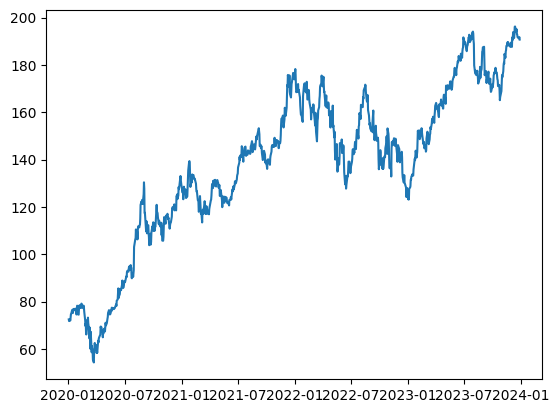

In [15]:
plo.plot(x,y)

In [16]:
stockdata["Close"].rolling(window=20).mean()

Ticker,AAPL
Date,
2020-01-02,NaN
2020-01-03,NaN
2020-01-06,NaN
2020-01-07,NaN
2020-01-08,NaN
...,...
2023-12-22,191.856621
2023-12-26,192.018098
2023-12-27,192.154311


In [17]:
x=stockdata.index
y1=stockdata["Close"]
y2=stockdata["Close"].rolling(window=20).mean()


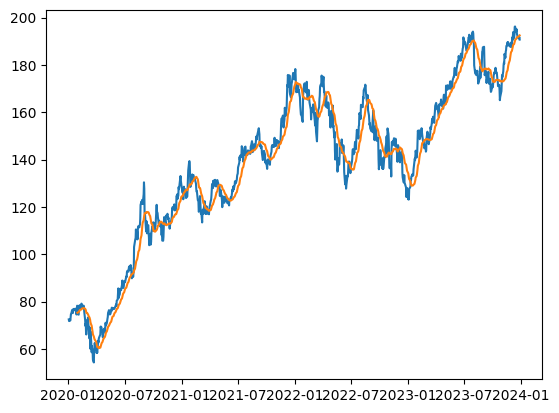

In [18]:
plo.plot(x,y1)
plo.plot(x,y2)

In [19]:
rsdata=stockdata.reset_index()

In [20]:
stockdata["Close"]

Ticker,AAPL
Date,
2020-01-02,72.468269
2020-01-03,71.763718
2020-01-06,72.335548
2020-01-07,71.995346
2020-01-08,73.153496
...,...
2023-12-22,191.788773
2023-12-26,191.243927
2023-12-27,191.342957


In [21]:
ds=rsdata["Date"]

In [22]:
stockdata["Close"]


Ticker,AAPL
Date,
2020-01-02,72.468269
2020-01-03,71.763718
2020-01-06,72.335548
2020-01-07,71.995346
2020-01-08,73.153496
...,...
2023-12-22,191.788773
2023-12-26,191.243927
2023-12-27,191.342957


In [23]:
z=rsdata["Close"]

In [24]:
y=z.squeeze()

In [25]:
print(y)

0        72.468269
1        71.763718
2        72.335548
3        71.995346
4        73.153496
           ...    
1001    191.788773
1002    191.243927
1003    191.342957
1004    191.768951
1005    190.728745
Name: AAPL, Length: 1006, dtype: float64


In [26]:
print(ds)

0      2020-01-02
1      2020-01-03
2      2020-01-06
3      2020-01-07
4      2020-01-08
          ...    
1001   2023-12-22
1002   2023-12-26
1003   2023-12-27
1004   2023-12-28
1005   2023-12-29
Name: Date, Length: 1006, dtype: datetime64[ns]


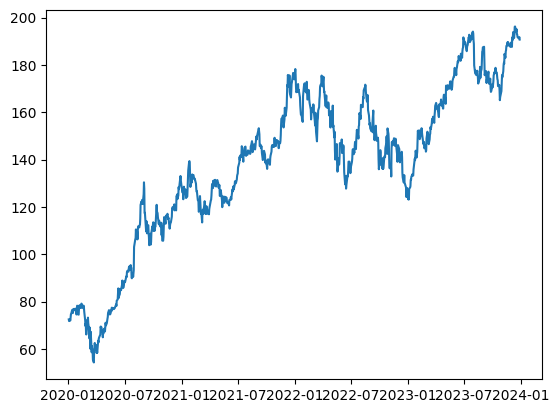

In [27]:
plo.plot(ds,y)

In [28]:
new_form_data=(ds,y)

In [29]:
p_data=rsdata.drop(columns=["High","Low","Volume","Open"])

C:\Users\imran\AppData\Local\Temp\ipykernel_7088\712812369.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  p_data=rsdata.drop(columns=["High","Low","Volume","Open"])


In [30]:
print(p_data)

Price        Date       Close
Ticker                   AAPL
0      2020-01-02   72.468269
1      2020-01-03   71.763718
2      2020-01-06   72.335548
3      2020-01-07   71.995346
4      2020-01-08   73.153496
...           ...         ...
1001   2023-12-22  191.788773
1002   2023-12-26  191.243927
1003   2023-12-27  191.342957
1004   2023-12-28  191.768951
1005   2023-12-29  190.728745

[1006 rows x 2 columns]


In [31]:
print(ds)

0      2020-01-02
1      2020-01-03
2      2020-01-06
3      2020-01-07
4      2020-01-08
          ...    
1001   2023-12-22
1002   2023-12-26
1003   2023-12-27
1004   2023-12-28
1005   2023-12-29
Name: Date, Length: 1006, dtype: datetime64[ns]


In [32]:
prophet_data=pd.DataFrame({"ds":ds,"y":y})

In [33]:
print(prophet_data)

             ds           y
0    2020-01-02   72.468269
1    2020-01-03   71.763718
2    2020-01-06   72.335548
3    2020-01-07   71.995346
4    2020-01-08   73.153496
...         ...         ...
1001 2023-12-22  191.788773
1002 2023-12-26  191.243927
1003 2023-12-27  191.342957
1004 2023-12-28  191.768951
1005 2023-12-29  190.728745

[1006 rows x 2 columns]


In [34]:
p_data.rename(columns={"Date":"ds","Close":"y"})

Price,ds,y
Ticker,,AAPL
0,2020-01-02,72.468269
1,2020-01-03,71.763718
2,2020-01-06,72.335548
3,2020-01-07,71.995346
4,2020-01-08,73.153496
...,...,...
1001,2023-12-22,191.788773
1002,2023-12-26,191.243927
1003,2023-12-27,191.342957


In [35]:
!pip install prophet

In [36]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [37]:
mode1=Prophet()

In [38]:
mode1.fit(prophet_data)

21:28:00 - cmdstanpy - INFO - Chain [1] start processing
21:28:01 - cmdstanpy - INFO - Chain [1] done processing


In [39]:
future_data=mode1.make_future_dataframe(periods=7)

In [40]:
future_data.head()


,ds
0,2020-01-02
1,2020-01-03
2,2020-01-06
3,2020-01-07
4,2020-01-08


In [41]:
future_data.tail(7)

,ds
1006,2023-12-30
1007,2023-12-31
1008,2024-01-01
1009,2024-01-02
1010,2024-01-03
1011,2024-01-04
1012,2024-01-05


In [42]:
print(future_data)

             ds
0    2020-01-02
1    2020-01-03
2    2020-01-06
3    2020-01-07
4    2020-01-08
...         ...
1008 2024-01-01
1009 2024-01-02
1010 2024-01-03
1011 2024-01-04
1012 2024-01-05

[1013 rows x 1 columns]


In [43]:
forecast=mode1.predict(future_data)

In [44]:
last_10days=forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(10)

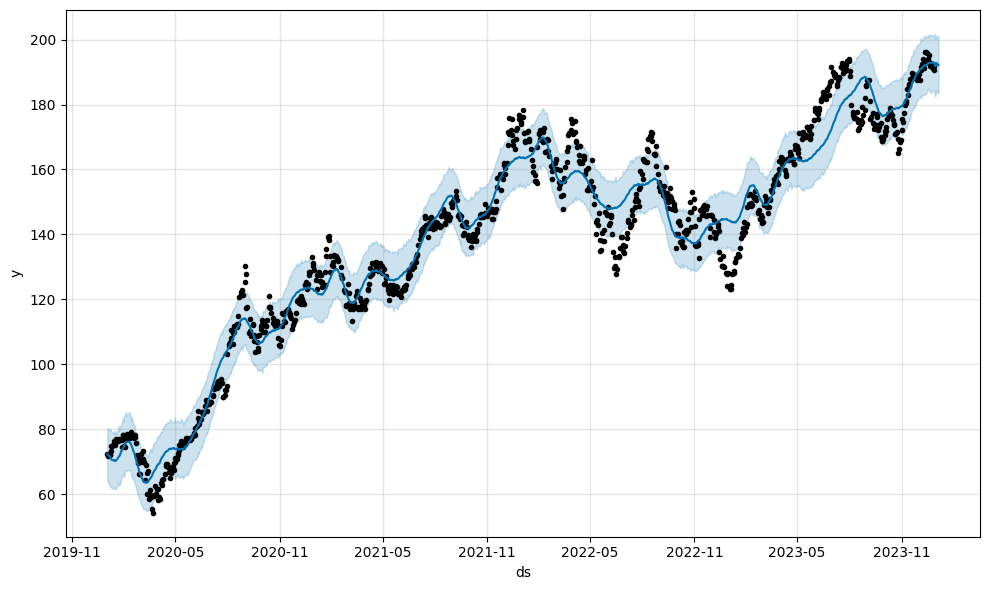

In [45]:
fig=mode1.plot(forecast)

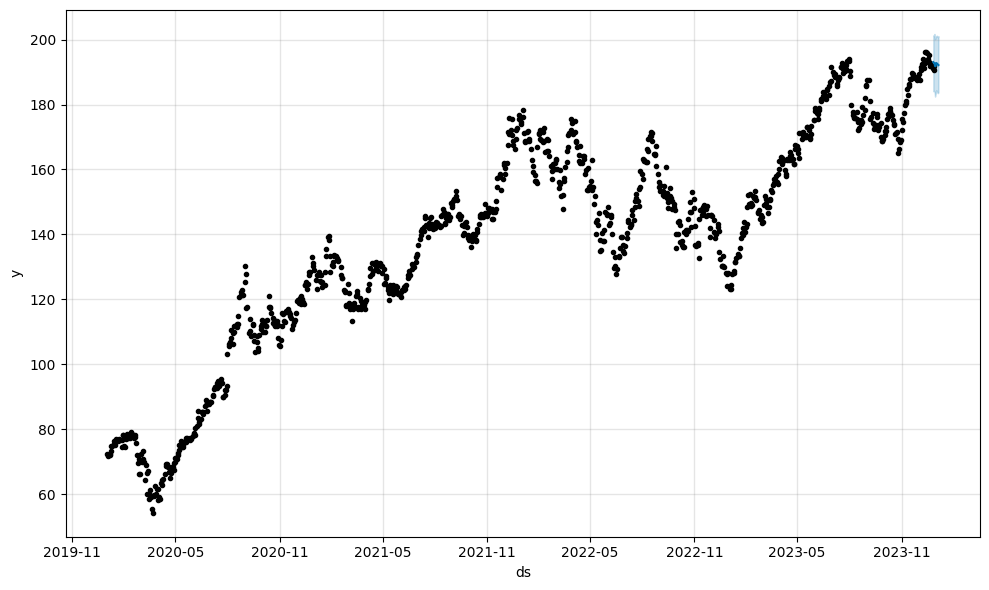

In [46]:
fig=mode1.plot(last_10days)

In [47]:
print(last_10days)

             ds        yhat  yhat_lower  yhat_upper
1003 2023-12-27  193.046394  184.070830  201.306922
1004 2023-12-28  192.825432  184.176567  201.063975
1005 2023-12-29  192.724474  184.045932  201.732837
1006 2023-12-30  191.854432  182.426435  200.110821
1007 2023-12-31  191.780622  183.138872  200.764994
1008 2024-01-01  192.795363  184.363366  201.050339
1009 2024-01-02  192.568336  184.243632  201.208943
1010 2024-01-03  192.559558  183.675010  200.974420
1011 2024-01-04  192.279782  183.481697  200.742827
1012 2024-01-05  192.137722  183.731503  201.061090


In [48]:
print(prophet_data)

             ds           y
0    2020-01-02   72.468269
1    2020-01-03   71.763718
2    2020-01-06   72.335548
3    2020-01-07   71.995346
4    2020-01-08   73.153496
...         ...         ...
1001 2023-12-22  191.788773
1002 2023-12-26  191.243927
1003 2023-12-27  191.342957
1004 2023-12-28  191.768951
1005 2023-12-29  190.728745

[1006 rows x 2 columns]


In [49]:
last10actual=prophet_data.tail(10)


In [50]:
last10predicted=forecast.tail(10)

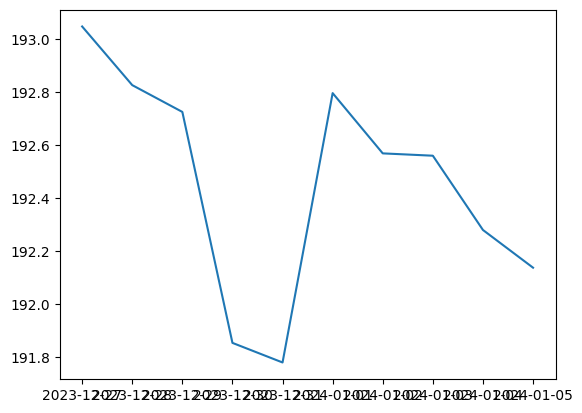

In [51]:
plo.plot(last10predicted["ds"],last10predicted["yhat"])

In [52]:
print(last10actual)

             ds           y
996  2023-12-15  195.721619
997  2023-12-18  194.057358
998  2023-12-19  195.097534
999  2023-12-20  193.007263
1000 2023-12-21  192.858643
1001 2023-12-22  191.788773
1002 2023-12-26  191.243927
1003 2023-12-27  191.342957
1004 2023-12-28  191.768951
1005 2023-12-29  190.728745


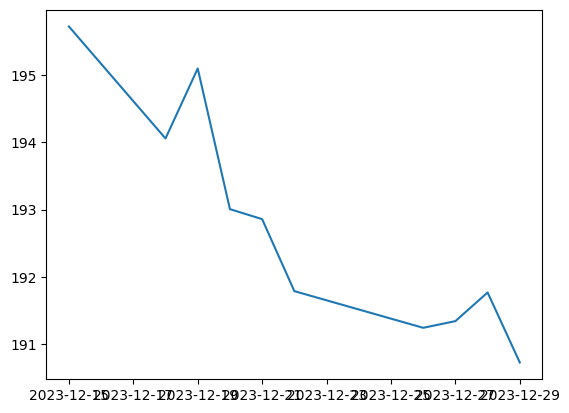

In [53]:
plo.plot(last10actual["ds"],last10actual["y"])

In [54]:
forecast_past = forecast[forecast["ds"].isin(prophet_data["ds"])]

In [55]:
acc_data=prophet_data.merge(forecast_past[["ds","yhat"]],on="ds")

In [56]:
acc_data["abs_error"] = abs(acc_data["y"] - acc_data["yhat"])

In [57]:
mae = acc_data["abs_error"].mean() 

In [58]:
print(mae)

5.123118981258575


In [59]:
prophet_data = prophet_data.sort_values("ds").reset_index(drop=True)

In [60]:
rolling_days = 30

In [61]:
actuals = []
predictions = []
for i in range(len(prophet_data) - rolling_days, len(prophet_data)):
    train_data = prophet_data.iloc[:i]
    actual = prophet_data.iloc[i]["y"]
    model = Prophet(daily_seasonality=True)
    model.fit(train_data)
    future = model.make_future_dataframe(periods=1)
    forecast = model.predict(future)
    predicted = forecast.iloc[-1]["yhat"]
    actuals.append(actual)
    predictions.append(predicted)

21:28:12 - cmdstanpy - INFO - Chain [1] start processing
21:28:12 - cmdstanpy - INFO - Chain [1] done processing
21:28:13 - cmdstanpy - INFO - Chain [1] start processing
21:28:14 - cmdstanpy - INFO - Chain [1] done processing
21:28:15 - cmdstanpy - INFO - Chain [1] start processing
21:28:15 - cmdstanpy - INFO - Chain [1] done processing
21:28:16 - cmdstanpy - INFO - Chain [1] start processing
21:28:16 - cmdstanpy - INFO - Chain [1] done processing
21:28:17 - cmdstanpy - INFO - Chain [1] start processing
21:28:18 - cmdstanpy - INFO - Chain [1] done processing
21:28:19 - cmdstanpy - INFO - Chain [1] start processing
21:28:19 - cmdstanpy - INFO - Chain [1] done processing
21:28:20 - cmdstanpy - INFO - Chain [1] start processing
21:28:20 - cmdstanpy - INFO - Chain [1] done processing
21:28:21 - cmdstanpy - INFO - Chain [1] start processing
21:28:22 - cmdstanpy - INFO - Chain [1] done processing
21:28:23 - cmdstanpy - INFO - Chain [1] start processing
21:28:23 - cmdstanpy - INFO - Chain [1]

In [63]:
actuals = np.array(actuals)
predictions = np.array(predictions)
mae = np.mean(np.abs(actuals - predictions))
print("MAE:", round(mae, 2))

MAE: 1.98
